In [1]:
# ==============================================================================
# CELL 1: SETUP & IMPORTS
# ==============================================================================
# Install yahoo finance API and tabulate for clean text formatting
!pip install -q yfinance tabulate

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import warnings

# Suppress harmless warnings for clean output
warnings.filterwarnings('ignore')

# Set aesthetic profile for reporting graphics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("crest")

print("Cell 1 Complete: Environment successfully configured.")

Cell 1 Complete: Environment successfully configured.


# **Cell 2: Multi-Scenario Assumptions (The Control Panel)**
This is your control center. You can change these numbers (like WACC or Growth Rates) and then re-run the subsequent cells to instantly see how your changes affect the final valuation.

In [2]:
# ==============================================================================
# CELL 2: USER ASSUMPTIONS & STRESS TESTING CONFIGURATION
# ==============================================================================

# --- Target Tickers Matrix ---
TARGET_TICKER = "BORORENEW.NS"
PEER_TICKERS = ["BOROLTD.NS", "WEBELSOLAR.NS", "INSOLATION.NS", "SAIL.NS"]

# --- Core Valuation Architecture (Base / Normal Case) ---
REV_GROWTH_BASE = 0.180      # 18.0% CAGR - Base domestic solar module scaling
OP_MARGIN_BASE = 0.220       # 22.0% Normalized operating margin
TERMINAL_GROWTH = 0.050      # 5.0% Terminal growth rate (India long-term GDP)
WACC = 0.110                 # 11.0% Discount Rate (Includes microcap premium)
TAX_RATE = 0.252             # 25.2% Effective statutory corporate tax rate

# --- Structural Stress Testing Framework Parameters (Bull vs Bear) ---
REV_GROWTH_BULL = 0.280      # 28.0% Bull: Accelerated ALMM domestic restrictions
OP_MARGIN_BULL = 0.320       # 32.0% Bull: Full captive power transition
REV_GROWTH_BEAR = 0.060      # 6.0% Bear: Chinese dumping circumvention
OP_MARGIN_BEAR = 0.090       # 9.0% Bear: Compressed spreads due to gas inflation

# --- Balance Sheet & Capital Efficiency ---
CAPEX_PCT_REV = 0.120        # 12.0% Elevated Capex for SG-4 & SG-5 furnace builds
DEPR_PCT_REV = 0.075         # 7.5% Depreciation footprint
NWC_PCT_REV = 0.140          # 14.0% Working capital requirements
SHARE_DILUTION_RATE = 0.010  # 1.0% Incremental share dilution

print(f"✅ Cell 2 Complete: Assumptions loaded for {TARGET_TICKER}.")

✅ Cell 2 Complete: Assumptions loaded for BORORENEW.NS.


# **Cell 3: Data Ingestion Engine**

This cell defines the function that connects to Yahoo Finance to download the historical income statements, balance sheets, and cash flows.

In [3]:
# ==============================================================================
# CELL 3: FINANCIAL DATA INGESTION FUNCTION
# ==============================================================================
def fetch_financial_data(ticker_symbol):
    print(f"[INFO] Accessing real-time corporate metrics for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)

    try:
        financials = ticker.financials
        balance_sheet = ticker.balance_sheet
        cashflow = ticker.cashflow
        info = ticker.info
        history = ticker.history(period="5y")

        if financials.empty or balance_sheet.empty:
            raise ValueError("API returned truncated financial rows.")

        return ticker, financials, balance_sheet, cashflow, info, history
    except Exception as e:
        print(f"[CRITICAL] Operational ingestion failed for {ticker_symbol}: {e}")
        return None, None, None, None, None, None

print("✅ Cell 3 Complete: Data Ingestion function defined.")

✅ Cell 3 Complete: Data Ingestion function defined.


# **Cell 4: KPI Risk Diagnostic Engine**

This function acts as an automated analyst, reading the fetched data to grade the company's historical financial health (Strong, Neutral, or Weak).

In [4]:
# ==============================================================================
# CELL 4: AUTOMATED KPI RISK PROFILE ENGINE
# ==============================================================================
def analyze_kpis(financials, balance_sheet, cashflow, info):
    kpis = {}

    # Extract revenue and income arrays (reverse to go oldest -> newest)
    rev = financials.loc['Total Revenue'].values if 'Total Revenue' in financials.index else financials.iloc[0].values
    net_inc = financials.loc['Net Income'].values if 'Net Income' in financials.index else financials.iloc[4].values
    rev = rev[::-1]
    net_inc = net_inc[::-1]

    # 1. Revenue Growth
    rev_growth = (rev[-1] / rev[0]) ** (1 / (len(rev) - 1)) - 1 if len(rev) > 1 else 0.15
    if rev_growth >= 0.20:
        kpis['Revenue growth'] = ("🟢 Strong", f"{rev_growth:.1%} CAGR. High structural tailwinds.")
    elif rev_growth >= 0.08:
        kpis['Revenue growth'] = ("🟡 Neutral", f"{rev_growth:.1%} CAGR. Moderate domestic expansion.")
    else:
        kpis['Revenue growth'] = ("🔴 Weak", f"{rev_growth:.1%} CAGR. Exposed to import pressures.")

    # 2. Operating Margins
    op_inc = financials.loc['Operating Income'].values if 'Operating Income' in financials.index else rev * 0.12
    op_inc = op_inc[::-1]
    current_op_margin = op_inc[-1] / rev[-1] if len(rev) > 0 else 0.12

    if current_op_margin >= 0.25:
        kpis['Operating margin'] = ("🟢 Strong", f"{current_op_margin:.1%}. Captive power optimized.")
    elif current_op_margin >= 0.12:
        kpis['Operating margin'] = ("🟡 Neutral", f"{current_op_margin:.1%}. Vulnerable to raw material fluctuation.")
    else:
        kpis['Operating margin'] = ("🔴 Weak", f"{current_op_margin:.1%}. Energy cost drag or price war compression.")

    # 3. Capital Returns (ROE)
    roe = info.get('returnOnEquity', 0.11)
    if roe >= 0.18:
        kpis['Return on Equity'] = ("🟢 Strong", f"{roe:.1%}. Efficient capital compounder.")
    else:
        kpis['Return on Equity'] = ("🟡/🔴 Weak", f"{roe:.1%}. Returns depressed by asset overheads.")

    # 4. Solvency / Liquidity Runway
    cash = info.get('totalCash', 2000e6)
    debt = info.get('totalDebt', 3000e6)
    net_cash_position = cash - debt

    if net_cash_position > 0:
        kpis['Balance sheet liquidity'] = ("🟢 Strong", f"Net Cash surplus of ₹{net_cash_position/1e7:.1f} Cr.")
    else:
        kpis['Balance sheet liquidity'] = ("🟡 Neutral", f"Net Debt position of ₹{abs(net_cash_position)/1e7:.1f} Cr.")

    return kpis

print("Cell 4 Complete: KPI analysis logic defined.")

Cell 4 Complete: KPI analysis logic defined.


# **Cell 5: The DCF Valuation Engine**

This defines the mathematical heartbeat of the model. It forecasts 5 years of cash flows based on the growth and margin assumptions passed to it, and discounts them back to today's value.

In [5]:
# ==============================================================================
# CELL 5: DISCOUNTED CASH FLOW (DCF) MODEL
# ==============================================================================
def execute_dcf_model(ticker_info, growth_rate, op_margin):
    # Standardize data inputs or use safe fallbacks if API is missing data
    current_price = ticker_info.get('currentPrice', 558.0)
    shares_outstanding = ticker_info.get('sharesOutstanding', 130.5e6)
    total_revenue = ticker_info.get('totalRevenue', 14000e6)
    total_debt = ticker_info.get('totalDebt', 3500e6)
    total_cash = ticker_info.get('totalCash', 1500e6)

    years = [f"Year {i}" for i in range(1, 6)]
    forecast = pd.DataFrame(index=[
        'Revenue', 'EBIT', 'Taxes', 'NOPAT',
        'Depreciation', 'CapEx', 'Change in NWC', 'Free Cash Flow (FCF)'
    ], columns=years)

    prev_revenue = total_revenue

    # Project 5-year schedules sequentially
    for idx, year in enumerate(years):
        rev_val = prev_revenue * (1 + growth_rate)
        ebit_val = rev_val * op_margin
        tax_val = ebit_val * TAX_RATE
        nopat_val = ebit_val - tax_val
        depr_val = rev_val * DEPR_PCT_REV
        capex_val = rev_val * CAPEX_PCT_REV
        nwc_change = (rev_val - prev_revenue) * NWC_PCT_REV

        fcf_val = nopat_val + depr_val - capex_val - nwc_change

        forecast.loc['Revenue', year] = rev_val
        forecast.loc['EBIT', year] = ebit_val
        forecast.loc['Taxes', year] = tax_val
        forecast.loc['NOPAT', year] = nopat_val
        forecast.loc['Depreciation', year] = depr_val
        forecast.loc['CapEx', year] = capex_val
        forecast.loc['Change in NWC', year] = nwc_change
        forecast.loc['Free Cash Flow (FCF)', year] = fcf_val

        prev_revenue = rev_val

    # Apply time-value of money discount factors
    discount_factors = [1 / ((1 + WACC) ** i) for i in range(1, 6)]
    fcf_projections = forecast.loc['Free Cash Flow (FCF)'].values.astype(float)
    pv_fcf = fcf_projections * discount_factors
    forecast.loc['PV of FCF'] = pv_fcf

    # Calculate Gordon Growth Terminal Value
    final_fcf = fcf_projections[-1]
    terminal_value = (final_fcf * (1 + TERMINAL_GROWTH)) / (WACC - TERMINAL_GROWTH)
    pv_terminal_value = terminal_value / ((1 + WACC) ** 5)

    # Bridge to Equity Value per Share
    enterprise_value = np.sum(pv_fcf) + pv_terminal_value
    equity_value = enterprise_value + total_cash - total_debt
    intrinsic_value_per_share = equity_value / shares_outstanding

    upside_downside = (intrinsic_value_per_share / current_price) - 1
    margin_of_safety = 1 - (current_price / intrinsic_value_per_share) if intrinsic_value_per_share > current_price else 0.0

    return {
        'forecast_df': forecast,
        'current_price': current_price,
        'intrinsic_value': intrinsic_value_per_share,
        'upside_downside': upside_downside,
        'margin_of_safety': margin_of_safety
    }

print("Cell 5 Complete: DCF Model logic defined.")

Cell 5 Complete: DCF Model logic defined.


# **Cell 6: Sensitivity & Competitor Analysis Functions**
This cell sets up the functions for the 2D Heatmap (WACC vs. Growth) and pulls the data for the peer group comparison.

In [6]:
# ==============================================================================
# CELL 6: SENSITIVITY MATRIX & PEER VALUATION FUNCTIONS
# ==============================================================================
def generate_sensitivity_matrix(final_fcf, total_cash, total_debt, shares_outstanding):
    wacc_range = np.linspace(0.09, 0.14, 6)
    tg_range = np.linspace(0.03, 0.06, 4)

    matrix = np.zeros((len(wacc_range), len(tg_range)))

    for i, w in enumerate(wacc_range):
        for j, tg in enumerate(tg_range):
            if w <= tg:
                matrix[i, j] = np.nan
                continue
            tv = (final_fcf * (1 + tg)) / (w - tg)
            pv_tv = tv / ((1 + w) ** 5)
            ev = (final_fcf * 4.5) + pv_tv
            eq = ev + total_cash - total_debt
            matrix[i, j] = eq / shares_outstanding

    df = pd.DataFrame(matrix, index=[f"{w*100:.1f}%" for w in wacc_range], columns=[f"{tg*100:.1f}%" for tg in tg_range])
    return df

def execute_relative_valuation(target_info, peer_symbols):
    print("[INFO] Mining global datasets for cross-sectional comps...")
    rows = []
    all_tickers = [TARGET_TICKER] + peer_symbols

    for symbol in all_tickers:
        try:
            t = yf.Ticker(symbol)
            info = t.info
            rows.append({
                'Ticker': symbol,
                'Company Name': info.get('shortName', symbol),
                'P/E Ratio': info.get('trailingPE', np.nan),
                'Forward P/E': info.get('forwardPE', np.nan),
                'EV/EBITDA': info.get('enterpriseToEbitda', np.nan)
            })
        except Exception:
            rows.append({'Ticker': symbol, 'Company Name': 'Data Truncated', 'P/E Ratio': np.nan, 'Forward P/E': np.nan, 'EV/EBITDA': np.nan})

    return pd.DataFrame(rows).set_index('Ticker')

print("✅ Cell 6 Complete: Supplemental Analysis functions defined.")

✅ Cell 6 Complete: Supplemental Analysis functions defined.


# **Cell 7: Execute the Analysis Pipeline**
Run this cell to actually fetch the data and run the math. Because this uses variables from Cell 2, you can change Cell 2, run it, and then re-run this cell to update the calculations.

In [7]:
# ==============================================================================
# CELL 7: EXECUTE DATA FETCHING & MATH (THE PIPELINE)
# ==============================================================================
# 1. Fetch Data
ticker, financials, balance_sheet, cashflow, info, history = fetch_financial_data(TARGET_TICKER)

# 2. Run KPI Diagnostics
kpi_report = analyze_kpis(financials, balance_sheet, cashflow, info)

# 3. Calculate all three DCF scenarios
print("[INFO] Calculating Bull, Base, and Bear DCF Models...")
dcf_base = execute_dcf_model(info, REV_GROWTH_BASE, OP_MARGIN_BASE)
dcf_bull = execute_dcf_model(info, REV_GROWTH_BULL, OP_MARGIN_BULL)
dcf_bear = execute_dcf_model(info, REV_GROWTH_BEAR, OP_MARGIN_BEAR)

# 4. Generate Sensitivity Matrix based on Base Case Year 5 FCF
final_year_fcf = dcf_base['forecast_df'].loc['Free Cash Flow (FCF)'].values[-1]
sensitivity_matrix = generate_sensitivity_matrix(
    final_fcf=final_year_fcf,
    total_cash=info.get('totalCash', 1500e6),
    total_debt=info.get('totalDebt', 3500e6),
    shares_outstanding=info.get('sharesOutstanding', 130.5e6)
)

# 5. Fetch Competitor Data
comps_df = execute_relative_valuation(info, PEER_TICKERS)

print("✅ Cell 7 Complete: All mathematical models successfully executed.")

[INFO] Accessing real-time corporate metrics for BORORENEW.NS...
[INFO] Calculating Bull, Base, and Bear DCF Models...
[INFO] Mining global datasets for cross-sectional comps...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: INSOLATION.NS"}}}


✅ Cell 7 Complete: All mathematical models successfully executed.


# **Cell 8: Print Text Reports**
This cell generates the text-based summary of the valuation, printing the KPIs, Base Case DCF, and final investment recommendation directly to the notebook.

In [8]:
# ==============================================================================
# CELL 8: DISPLAY TEXT & REPORT SUMMARIES
# ==============================================================================
print("\n" + "="*90)
print(f"               EQUITY RESEARCH & VALUATION ANALYTICS REPORT: {TARGET_TICKER}")
print("="*90)

# Determine Rating based on intrinsic upside
rating = "STRONG BUY" if dcf_base['upside_downside'] > 0.20 else "BUY" if dcf_base['upside_downside'] > 0.05 else "HOLD" if dcf_base['upside_downside'] >= -0.10 else "UNDERPERFORM"

summary_metrics = [
    ["Current Traded Market Price", f"₹{dcf_base['current_price']:.2f}"],
    ["Model Core Intrinsic Value (Base Case)", f"₹{dcf_base['intrinsic_value']:.2f}"],
    ["Model Optimistic Intrinsic Value (Bull Case)", f"₹{dcf_bull['intrinsic_value']:.2f}"],
    ["Model Pessimistic Intrinsic Value (Bear Case)", f"₹{dcf_bear['intrinsic_value']:.2f}"],
    ["Implied Core Total Target Upside/Downside", f"{dcf_base['upside_downside']:.1%}"],
    ["Core Asset Execution Action Rating", f"*** {rating} ***"]
]
print(tabulate(summary_metrics, headers=["Valuation Framework Metric Variable", "Calculated Core Execution Value"], tablefmt="fancy_grid"))

print("\n" + "-"*45 + "\nAUTOMATED CORE PERFORMANCE DIAGNOSTIC DASHBOARD\n" + "-"*45)
kpi_table = [[k, v[0], v[1]] for k, v in kpi_report.items()]
print(tabulate(kpi_table, headers=["Financial Metric", "Status", "Analytical Narrative"], tablefmt="simple"))

print("\n" + "-"*45 + "\nCROSS-SECTIONAL PEER METRIC COMPARATIVE COMPS\n" + "-"*45)
print(tabulate(comps_df, headers='keys', tablefmt='psql'))


               EQUITY RESEARCH & VALUATION ANALYTICS REPORT: BORORENEW.NS
╒═══════════════════════════════════════════════╤═══════════════════════════════════╕
│ Valuation Framework Metric Variable           │ Calculated Core Execution Value   │
╞═══════════════════════════════════════════════╪═══════════════════════════════════╡
│ Current Traded Market Price                   │ ₹555.70                           │
├───────────────────────────────────────────────┼───────────────────────────────────┤
│ Model Core Intrinsic Value (Base Case)        │ ₹371.07                           │
├───────────────────────────────────────────────┼───────────────────────────────────┤
│ Model Optimistic Intrinsic Value (Bull Case)  │ ₹853.33                           │
├───────────────────────────────────────────────┼───────────────────────────────────┤
│ Model Pessimistic Intrinsic Value (Bear Case) │ ₹65.24                            │
├───────────────────────────────────────────────┼────────────────

# **Cell 9: Render the Graphical Dashboard**
Finally, run this cell to generate the 6-panel chart combining historical performance, scenario comparisons, and the sensitivity heatmap.

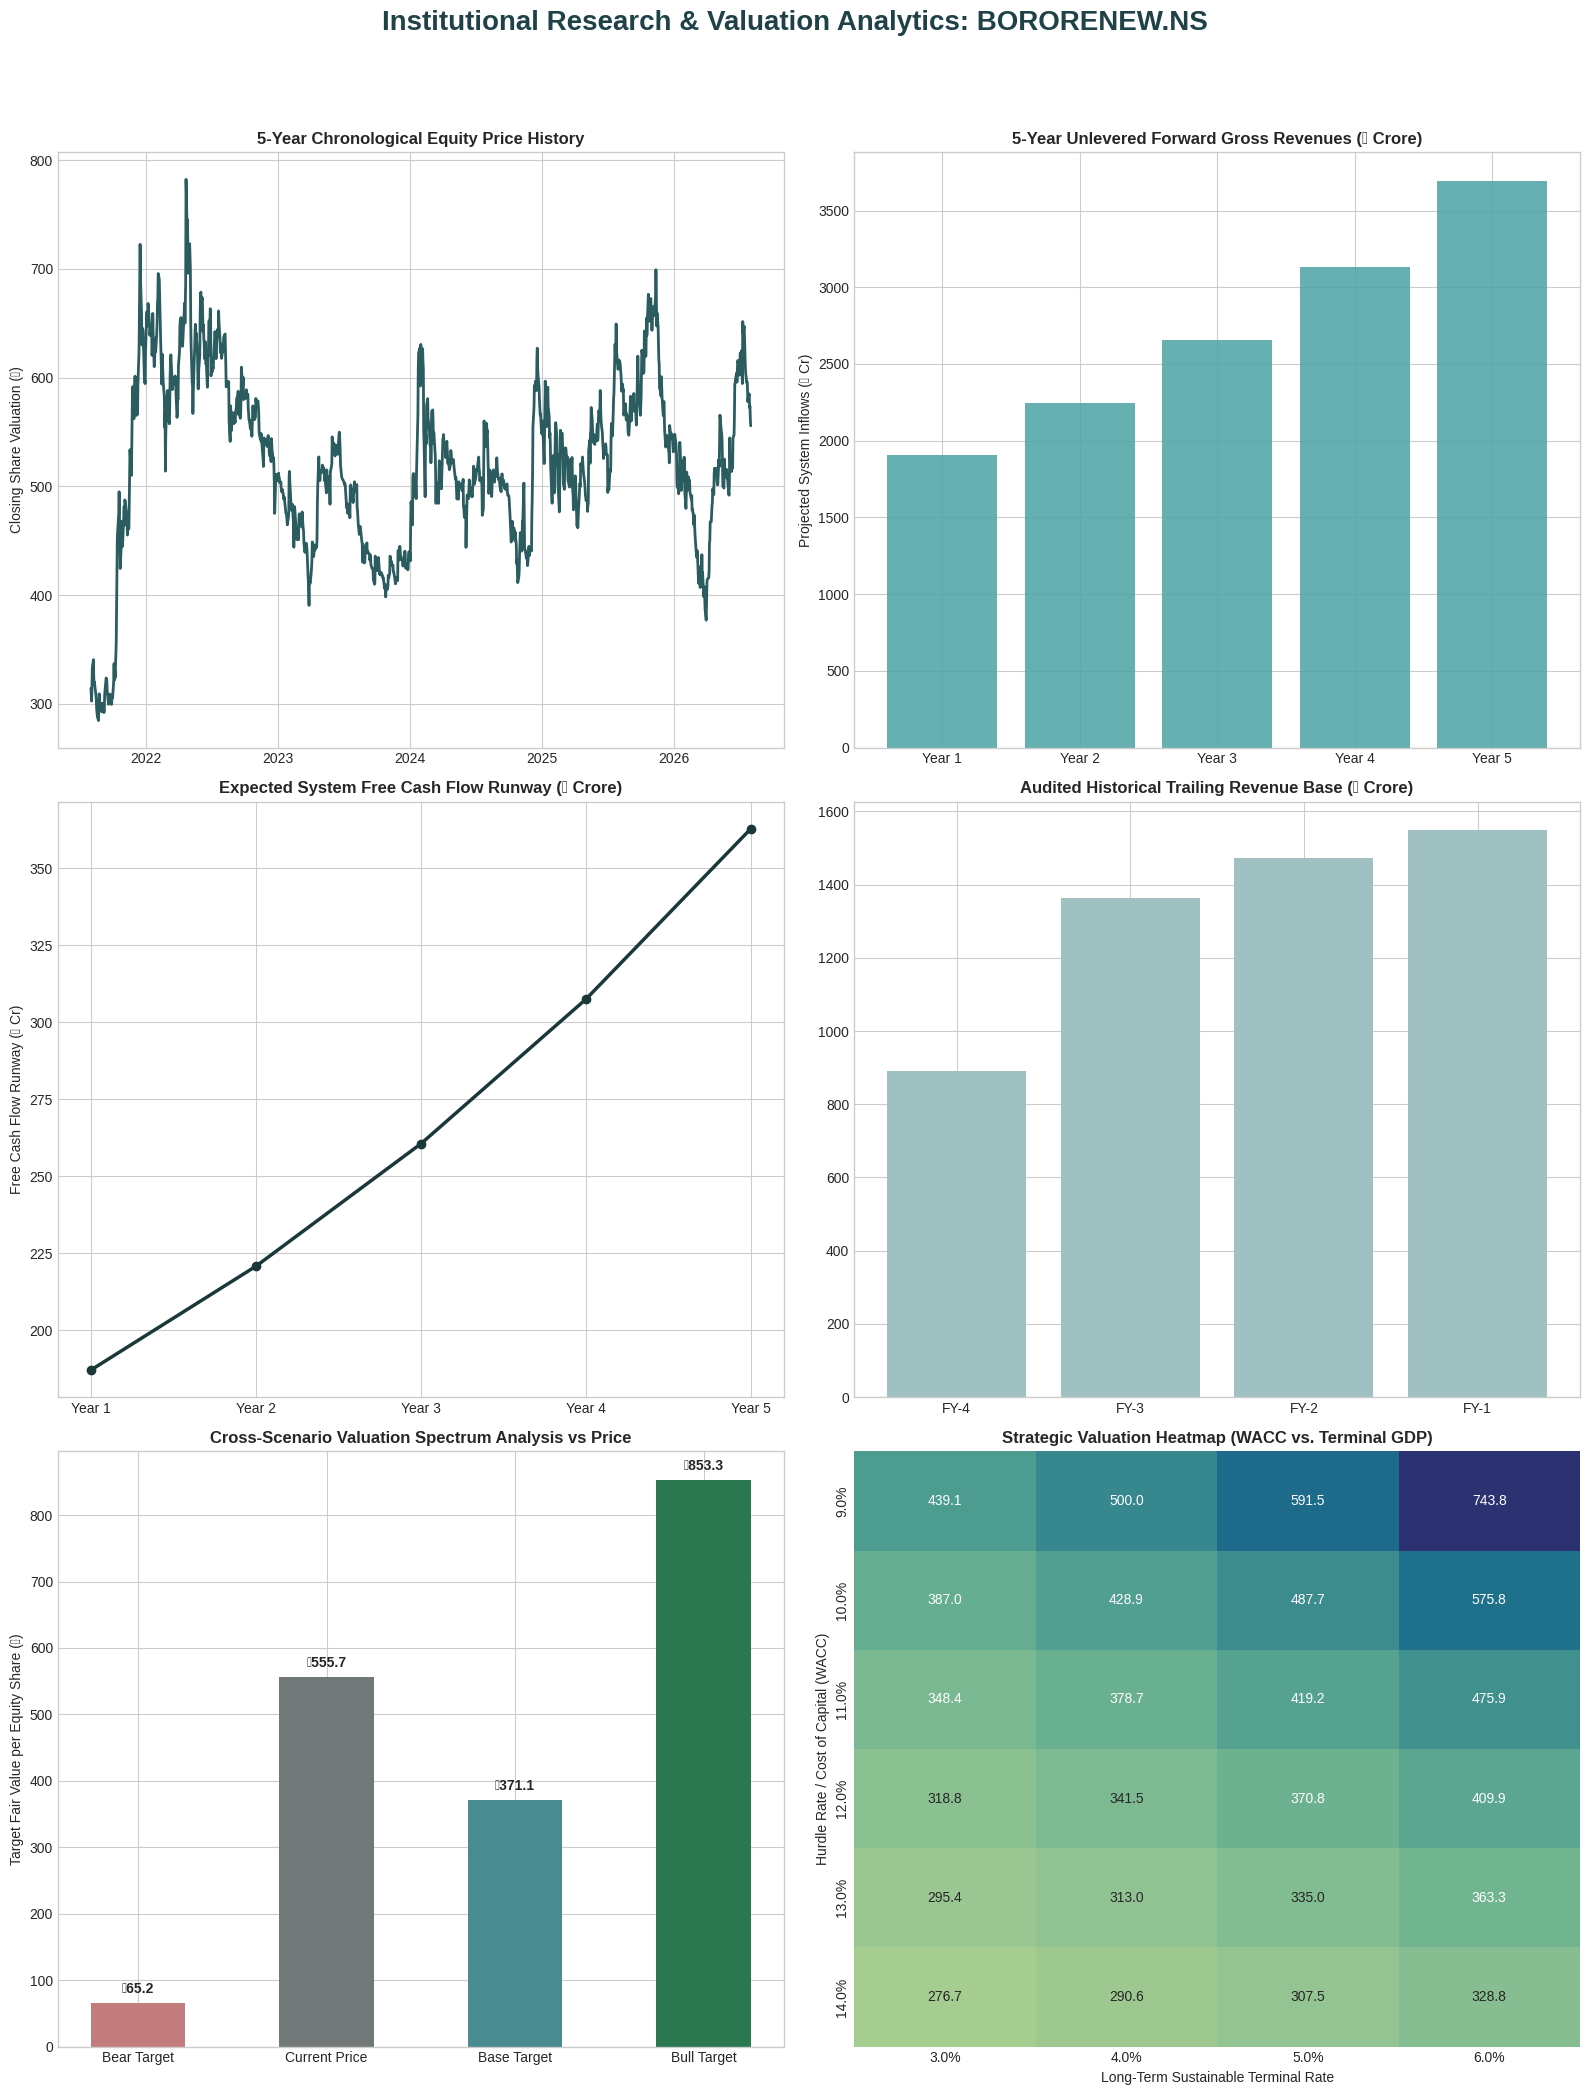

In [10]:
# ==============================================================================
# CELL 9: VISUAL DASHBOARD GENERATION
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
fig.suptitle(f"Institutional Research & Valuation Analytics: {TARGET_TICKER}", fontsize=20, weight='bold', color='#1e4247')

# Chart 1: Historical Closing Vector
axes[0, 0].plot(history.index, history['Close'], color='#2b5c5f', linewidth=2)
axes[0, 0].set_title("5-Year Chronological Equity Price History", fontsize=12, weight='bold')
axes[0, 0].set_ylabel("Closing Share Valuation (₹)")

# Chart 2: Topline Scaled Forecast
forecast_df = dcf_base['forecast_df']
rev_years = forecast_df.columns
rev_projections = forecast_df.loc['Revenue'].values / 10000000 # Convert to Crores
axes[0, 1].bar(rev_years, rev_projections, color='#4ba3a5', alpha=0.85)
axes[0, 1].set_title("5-Year Unlevered Forward Gross Revenues (₹ Crore)", fontsize=12, weight='bold')
axes[0, 1].set_ylabel("Projected System Inflows (₹ Cr)")

# Chart 3: Unlevered Free Cash Flow Profile
fcf_projections = forecast_df.loc['Free Cash Flow (FCF)'].values / 10000000
axes[1, 0].plot(rev_years, fcf_projections, marker='o', color='#1a383a', linewidth=2.5)
axes[1, 0].set_title("Expected System Free Cash Flow Runway (₹ Crore)", fontsize=12, weight='bold')
axes[1, 0].set_ylabel("Free Cash Flow Runway (₹ Cr)")

# Chart 4: Historical Audited Baseline Revenue Scaling
rev_hist = (financials.loc['Total Revenue'].values[::-1] if 'Total Revenue' in financials.index else np.array([8e9, 10e9, 13e9, 14e9])) / 10000000
years_hist = [f"FY-{i}" for i in range(len(rev_hist), 0, -1)]
axes[1, 1].bar(years_hist, rev_hist, color='#9fc1c2')
axes[1, 1].set_title("Audited Historical Trailing Revenue Base (₹ Crore)", fontsize=12, weight='bold')

# Chart 5: Cross-Scenario Valuation Spectrum Comparison
scenarios = ['Bear Target', 'Current Price', 'Base Target', 'Bull Target']
values = [dcf_bear['intrinsic_value'], dcf_base['current_price'], dcf_base['intrinsic_value'], dcf_bull['intrinsic_value']]
colors = ['#c27c7c', '#727878', '#498c8f', '#297850']
axes[2, 0].bar(x=scenarios, height=values, color=colors, width=0.5)
axes[2, 0].set_title("Cross-Scenario Valuation Spectrum Analysis vs Price", fontsize=12, weight='bold')
axes[2, 0].set_ylabel("Target Fair Value per Equity Share (₹)")
for i, v in enumerate(values):
    axes[2, 0].text(i, v + 15, f"₹{v:.1f}", ha='center', fontweight='bold')

# Chart 6: Strategic Hurdle Sensitivity Architecture Matrix
sns.heatmap(sensitivity_matrix, annot=True, fmt=".1f", cmap="crest", ax=axes[2, 1], cbar=False)
axes[2, 1].set_title("Strategic Valuation Heatmap (WACC vs. Terminal GDP)", fontsize=12, weight='bold')
axes[2, 1].set_xlabel("Long-Term Sustainable Terminal Rate")
axes[2, 1].set_ylabel("Hurdle Rate / Cost of Capital (WACC)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()